<a href="https://colab.research.google.com/github/Marium-pixel/AI_24K0906/blob/main/lab10%2611.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#lab 10 tasks

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('/content/drive/MyDrive/Housing.csv')

df = df.dropna()

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

x = df.drop('price', axis=1)
y = df['price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MSE: 1771751116594.0352
R2 Score: 0.6494754192267803


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

data = {
    'message': [
        'Win a free iPhone now',
        'Congratulations you won a lottery',
        'Call me when you are free',
        'Let us meet tomorrow',
        'Exclusive offer just for you click now',
        'You have been selected for a prize',
        'Are we still meeting today',
        'Please send the report by evening',
        'Limited time offer buy now',
        'Hey what are you doing',
        'Claim your reward now',
        'Important update regarding your account',
        'Free entry in a contest win cash',
        'Lunch at 2 pm?',
        'Urgent you have won a gift card'
    ],
    'label': [
        1,1,0,0,1,1,0,0,1,0,1,0,1,0,1
    ]
}

df = pd.DataFrame(data)

x = df['message']
y = df['label']

vectorizer = TfidfVectorizer(stop_words='english')
x = vectorizer.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = MultinomialNB()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

email = ["Congratulations you have won a free prize click here"]
email_vec = vectorizer.transform(email)

print("Prediction:", model.predict(email_vec))

Accuracy: 0.3333333333333333
Prediction: [1]


In [ ]:
#task 3
import numpy as np
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv('/content/drive/MyDrive/Customers.csv')

df = df.dropna()

df['label'] = (df['Spent'] > df['Spent'].mean()).astype(int)

x = df[['Recency', 'BuyFreq', 'Spent']]
y = df['label']

scaler = StandardScaler()
x = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = SVC(kernel='linear')
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred))

DT = DecisionTreeClassifier()
DT.fit(x_train, y_train)

PredictionDT = DT.predict(x_test)

print("DT Accuracy:", accuracy_score(y_test, PredictionDT))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SVM Accuracy: 0.9758364312267658
DT Accuracy: 1.0


In [ ]:
#lab 11 tasks

In [ ]:
#task1
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder


df = pd.read_csv('/content/drive/MyDrive/Mall_Customers.csv')


le = LabelEncoder()
df['Genre'] = le.fit_transform(df['Genre'])

# Drop ID
df_features = df.drop('CustomerID', axis=1)


kmeans1 = KMeans(n_clusters=5, random_state=42)
df['cluster_no_scale'] = kmeans1.fit_predict(df_features)


scaler = StandardScaler()

# Separate Age
age = df_features[['Age']]
other_features = df_features.drop('Age', axis=1)

scaled_other = scaler.fit_transform(other_features)

# Combine back
import numpy as np
x_scaled = np.concatenate([age.values, scaled_other], axis=1)

kmeans2 = KMeans(n_clusters=5, random_state=42)
df['cluster_scaled'] = kmeans2.fit_predict(x_scaled)


print(df.head())

   CustomerID  Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1      1   19                  15                      39   
1           2      1   21                  15                      81   
2           3      0   20                  16                       6   
3           4      0   23                  16                      77   
4           5      0   31                  17                      40   

   cluster_no_scale  cluster_scaled  
0                 2               2  
1                 2               2  
2                 0               2  
3                 2               2  
4                 0               1  


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler


# ============================
data = {
'vehicle_serial_no': [5,3,8,2,4,7,6,10,1,9],
'mileage': [150000,120000,250000,80000,100000,220000,180000,300000,75000,280000],
'fuel_efficiency': [15,18,10,22,20,12,16,8,24,9],
'maintenance_cost': [5000,4000,7000,2000,3000,6500,5500,8000,1500,7500],
'vehicle_type': ['SUV','Sedan','Truck','Hatchback','Sedan','Truck','SUV','Truck','Hatchback','SUV']
}

df = pd.DataFrame(data)

# Encode categorical
le = LabelEncoder()
df['vehicle_type'] = le.fit_transform(df['vehicle_type'])

x = df.drop('vehicle_serial_no', axis=1)

# WITHOUT SCALING
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster_no_scale'] = kmeans.fit_predict(x)

# WITH SCALING
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

kmeans2 = KMeans(n_clusters=3, random_state=42)
df['cluster_scaled'] = kmeans2.fit_predict(x_scaled)

print(df)

   vehicle_serial_no  mileage  fuel_efficiency  maintenance_cost  \
0                  5   150000               15              5000   
1                  3   120000               18              4000   
2                  8   250000               10              7000   
3                  2    80000               22              2000   
4                  4   100000               20              3000   
5                  7   220000               12              6500   
6                  6   180000               16              5500   
7                 10   300000                8              8000   
8                  1    75000               24              1500   
9                  9   280000                9              7500   

   vehicle_type  cluster_no_scale  cluster_scaled  
0             1                 2               2  
1             2                 2               2  
2             3                 1               1  
3             0                 0          

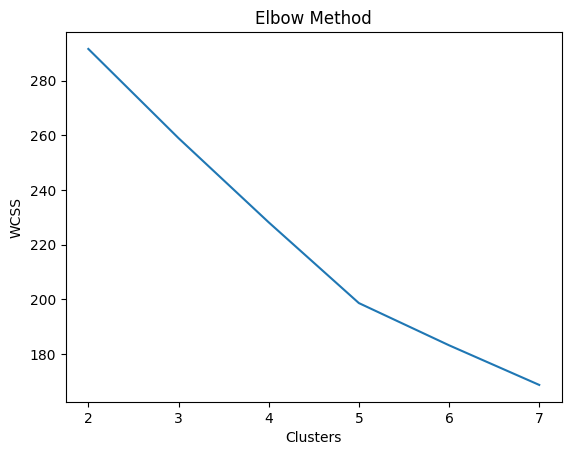

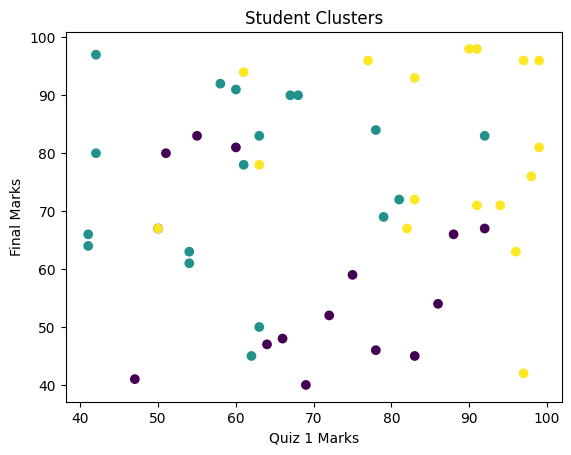

   quiz1_marks  quiz2_marks  quiz3_marks  midterm_marks  final_marks  \
0           78           76           53             72           46   
1           91           90           62             87           98   
2           68           46           99             94           90   
3           54           60           96             62           61   
4           82           48           79             63           67   

   lectures_attended  labs_attended  cluster  
0                 31             17        0  
1                 58             10        2  
2                 21             20        1  
3                 22             27        1  
4                 56             19        2  


In [7]:
#task 3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

df = pd.DataFrame({
    'quiz1_marks': np.random.randint(40, 100, 50),
    'quiz2_marks': np.random.randint(40, 100, 50),
    'quiz3_marks': np.random.randint(40, 100, 50),
    'midterm_marks': np.random.randint(40, 100, 50),
    'final_marks': np.random.randint(40, 100, 50),
    'lectures_attended': np.random.randint(20, 60, 50),
    'labs_attended': np.random.randint(10, 30, 50)
})

features = df.values

scaler = StandardScaler()
x_scaled = scaler.fit_transform(features)

wcss = []

for i in range(2, 8):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2, 8), wcss)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(x_scaled)

plt.scatter(df['quiz1_marks'], df['final_marks'], c=df['cluster'])
plt.xlabel("Quiz 1 Marks")
plt.ylabel("Final Marks")
plt.title("Student Clusters")
plt.show()

print(df.head())